# Market Microstructure Analysis

**Module 6 — Comprehensive Analysis**

This notebook demonstrates key market microstructure concepts:
- Order book dynamics and microstructure metrics
- Bid-ask spread decomposition
- Market impact models comparison
- Optimal execution strategy design
- High-frequency trading metrics

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline
sys.path.append(os.path.abspath('..'))
from market_microstructure import (
    OrderBookSnapshot, LimitOrderBook,
    LinearImpactModel, PowerLawImpactModel,
    OptimalExecutionAC, HighFrequencyMetrics,
    microstructure_summary
)

## 1. Order Book Dynamics

Analyze limit order book (LOB) snapshots and compute microstructure metrics including spreads, depths, and imbalances.

In [2]:
# Create and populate limit order book
lob = LimitOrderBook(num_levels=10, tick_size=0.01)

# Simulate realistic order book evolution
np.random.seed(42)
for t in range(100):
    mid_price = 100.0
    bid_prices = np.array([mid_price - 0.01*i for i in range(10)])
    ask_prices = np.array([mid_price + 0.01 + 0.01*i for i in range(10)])
    
    # Random volume fluctuations with mean reversion
    bid_volumes = np.array([1000 - 100*i + np.random.normal(0, 50) for i in range(10)])
    ask_volumes = np.array([800 - 80*i + np.random.normal(0, 40) for i in range(10)])
    
    bid_volumes = np.maximum(bid_volumes, 100)
    ask_volumes = np.maximum(ask_volumes, 100)
    
    snapshot = OrderBookSnapshot(
        timestamp=float(t),
        bid_prices=bid_prices,
        bid_volumes=bid_volumes,
        ask_prices=ask_prices,
        ask_volumes=ask_volumes
    )
    lob.add_snapshot(snapshot)

print(f'Created LOB with {len(lob.snapshots)} snapshots')
print(f'\nFirst snapshot:')
first = lob.snapshots[0]
print(f'  Spread: {first.spread:.4f}')
print(f'  Spread (bps): {first.spread_bps:.2f}')
print(f'  Bid Depth: {first.bid_depth:,.0f}')
print(f'  Ask Depth: {first.ask_depth:,.0f}')
print(f'  Imbalance: {first.imbalance:.4f}')

Created LOB with 100 snapshots

First snapshot:
  Spread: 0.0100
  Spread (bps): 1.00
  Bid Depth: 5,724
  Ask Depth: 4,160
  Imbalance: 0.1582


In [3]:
# Compute microstructure metrics
metrics = lob.compute_microstructure_metrics(window=20)
print('Microstructure Metrics (rolling window=20):')
display(metrics.describe().T.style.format('{:.6f}'))

Microstructure Metrics (rolling window=20):


,count,mean,std,min,25%,50%,75%,max
timestamp,80.000000,59.500000,23.237900,20.000000,39.750000,59.500000,79.250000,99.000000
spread_mean,80.000000,0.010000,0.000000,0.010000,0.010000,0.010000,0.010000,0.010000
spread_std,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
spread_bps_mean,80.000000,0.999950,0.000000,0.999950,0.999950,0.999950,0.999950,0.999950
imbalance_mean,80.000000,0.109025,0.004688,0.100800,0.105025,0.108651,0.112617,0.119125
imbalance_std,80.000000,0.018905,0.002050,0.012863,0.017776,0.018825,0.020471,0.022140
depth_bid_mean,80.000000,5538.037576,41.264020,5457.403328,5507.263414,5537.880859,5564.804262,5635.562599
depth_ask_mean,80.000000,4448.587589,17.524063,4410.604737,4436.292526,4448.620176,4458.079373,4501.384292
depth_ratio,80.000000,1.245824,0.011844,1.225187,1.235550,1.244747,1.255026,1.271423


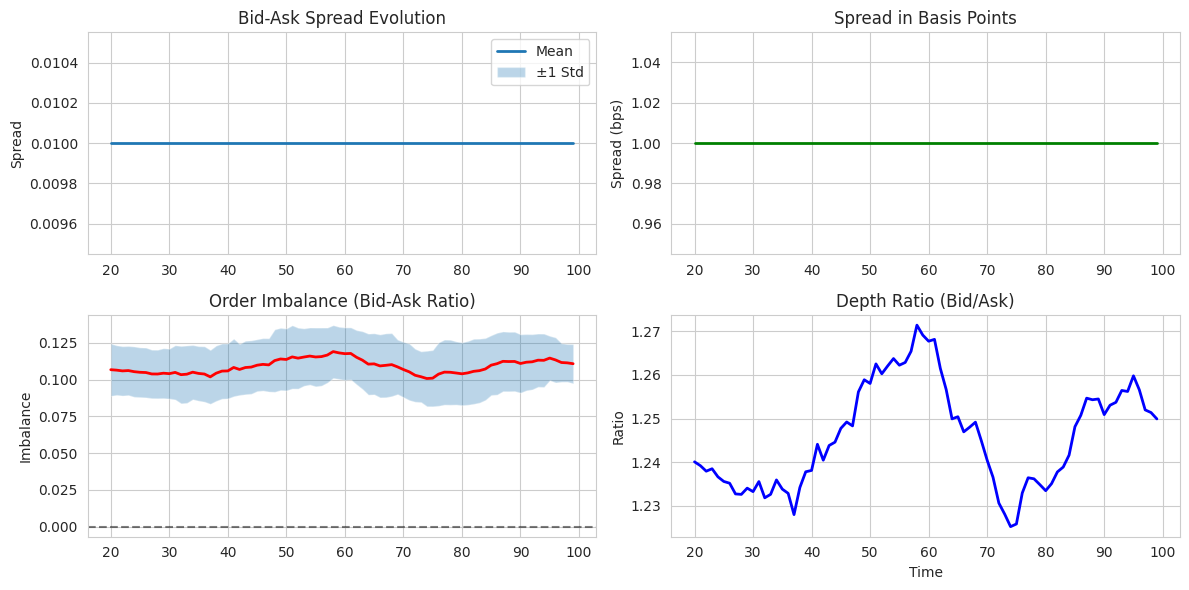

In [4]:
# Visualize spread and imbalance evolution
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0, 0].plot(metrics['timestamp'], metrics['spread_mean'], label='Mean', linewidth=2)
axes[0, 0].fill_between(metrics['timestamp'], 
                         metrics['spread_mean'] - metrics['spread_std'],
                         metrics['spread_mean'] + metrics['spread_std'],
                         alpha=0.3, label='±1 Std')
axes[0, 0].set_ylabel('Spread')
axes[0, 0].set_title('Bid-Ask Spread Evolution')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(metrics['timestamp'], metrics['spread_bps_mean'], 'g-', linewidth=2)
axes[0, 1].set_ylabel('Spread (bps)')
axes[0, 1].set_title('Spread in Basis Points')
axes[0, 1].grid(True)

axes[1, 0].plot(metrics['timestamp'], metrics['imbalance_mean'], 'r-', linewidth=2)
axes[1, 0].fill_between(metrics['timestamp'], 
                         metrics['imbalance_mean'] - metrics['imbalance_std'],
                         metrics['imbalance_mean'] + metrics['imbalance_std'],
                         alpha=0.3)
axes[1, 0].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1, 0].set_ylabel('Imbalance')
axes[1, 0].set_title('Order Imbalance (Bid-Ask Ratio)')
axes[1, 0].grid(True)

axes[1, 1].plot(metrics['timestamp'], metrics['depth_ratio'], 'b-', linewidth=2)
axes[1, 1].set_ylabel('Ratio')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_title('Depth Ratio (Bid/Ask)')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

Bid-Ask Spread Decomposition:
  total_spread: 0.010000
  adverse_selection: 0.003000
  inventory_cost: 0.002000
  adverse_selection_pct: 29.999970
  inventory_cost_pct: 19.999980


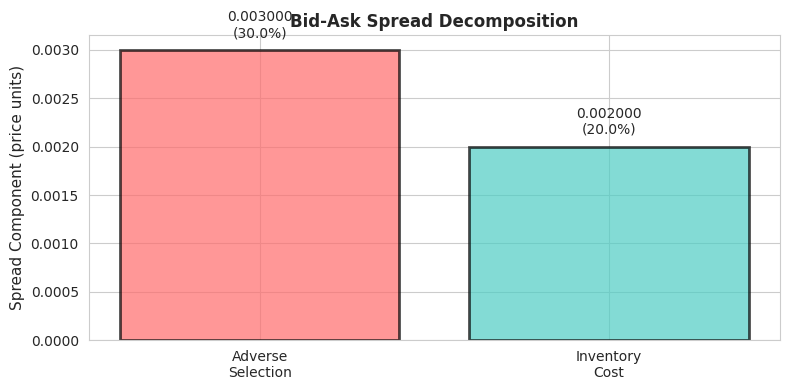

In [5]:
# Estimate spread components
components = lob.estimate_spread_components()
print('Bid-Ask Spread Decomposition:')
for key, value in components.items():
    print(f'  {key}: {value:.6f}')

# Visualize decomposition
fig, ax = plt.subplots(figsize=(8, 4))
categories = ['Adverse\nSelection', 'Inventory\nCost']
values = [components['adverse_selection'], components['inventory_cost']]
colors = ['#FF6B6B', '#4ECDC4']
bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Spread Component (price units)', fontsize=11)
ax.set_title('Bid-Ask Spread Decomposition', fontsize=12, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, values)):
    pct = 100 * val / components['total_spread']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'{val:.6f}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 2. Market Impact Models

Compare linear and power-law market impact models to understand how large orders move prices.

In [6]:
# Create impact models
linear = LinearImpactModel(alpha=0.001, beta_temp=0.0005, beta_perm=0.0002)
power = PowerLawImpactModel(lambda_temp=0.5, lambda_perm=0.3,
                            coeff_temp=0.0001, coeff_perm=0.00005)

# Compute impacts across order sizes
volumes = np.array([5e3, 10e3, 25e3, 50e3, 100e3, 250e3, 500e3])
daily_vol = 1e6

results = []
for vol in volumes:
    temp_lin, perm_lin = linear.compute_impact(vol, daily_vol)
    temp_pow, perm_pow = power.compute_impact(vol, daily_vol)
    results.append({
        'Order Volume': f'{vol/1e3:.0f}k',
        'Vol % Daily': f'{100*vol/daily_vol:.1f}%',
        'Linear Temp (bps)': temp_lin * 10000,
        'Linear Perm (bps)': perm_lin * 10000,
        'Power Temp (bps)': temp_pow * 10000,
        'Power Perm (bps)': perm_pow * 10000,
    })

impact_df = pd.DataFrame(results)
print('Market Impact Comparison:')
display(impact_df.style.format({
    'Linear Temp (bps)': '{:.4f}',
    'Linear Perm (bps)': '{:.4f}',
    'Power Temp (bps)': '{:.4f}',
    'Power Perm (bps)': '{:.4f}',
}))

Market Impact Comparison:


,Order Volume,Vol % Daily,Linear Temp (bps),Linear Perm (bps),Power Temp (bps),Power Perm (bps)
0,5k,0.5%,10.0250,0.0100,0.0707,0.1020
1,10k,1.0%,10.0500,0.0200,0.1000,0.1256
2,25k,2.5%,10.1250,0.0500,0.1581,0.1653
3,50k,5.0%,10.2500,0.1000,0.2236,0.2035
4,100k,10.0%,10.5000,0.2000,0.3162,0.2506
5,250k,25.0%,11.2500,0.5000,0.5000,0.3299
6,500k,50.0%,12.5000,1.0000,0.7071,0.4061


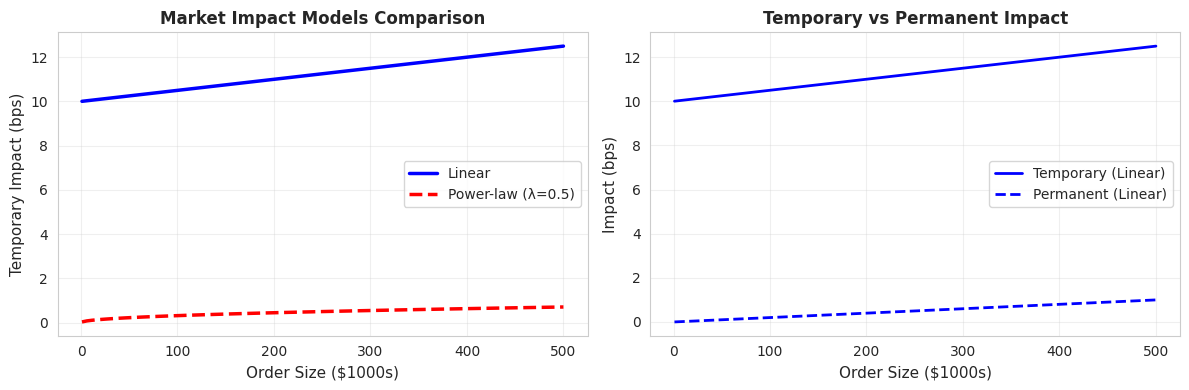

In [7]:
# Plot impact comparison
volumes_smooth = np.linspace(1e3, 500e3, 100)
impacts_lin_temp = np.array([linear.compute_impact(v, daily_vol)[0] for v in volumes_smooth])
impacts_pow_temp = np.array([power.compute_impact(v, daily_vol)[0] for v in volumes_smooth])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear vs Power-law
axes[0].plot(volumes_smooth/1e3, impacts_lin_temp*10000, 'b-', linewidth=2.5, label='Linear')
axes[0].plot(volumes_smooth/1e3, impacts_pow_temp*10000, 'r--', linewidth=2.5, label='Power-law (λ=0.5)')
axes[0].set_xlabel('Order Size ($1000s)', fontsize=11)
axes[0].set_ylabel('Temporary Impact (bps)', fontsize=11)
axes[0].set_title('Market Impact Models Comparison', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Temporary vs Permanent
perm_lin = np.array([linear.compute_impact(v, daily_vol)[1] for v in volumes_smooth])
perm_pow = np.array([power.compute_impact(v, daily_vol)[1] for v in volumes_smooth])

axes[1].plot(volumes_smooth/1e3, impacts_lin_temp*10000, 'b-', linewidth=2, label='Temporary (Linear)')
axes[1].plot(volumes_smooth/1e3, perm_lin*10000, 'b--', linewidth=2, label='Permanent (Linear)')
axes[1].set_xlabel('Order Size ($1000s)', fontsize=11)
axes[1].set_ylabel('Impact (bps)', fontsize=11)
axes[1].set_title('Temporary vs Permanent Impact', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Optimal Execution Strategy

Design execution schedules using the Almgren-Chriss framework with different risk aversion levels.

In [8]:
# Set up execution problem
executor = OptimalExecutionAC(
    initial_quantity=100000,
    time_horizon=1.0,
    num_periods=20,
    impact_model=linear,
    daily_volume=1e6
)

# Solve with different risk parameters
lambda_values = [1e-7, 1e-6, 1e-5, 1e-4]
schedules = {}

print('Optimal Execution Schedules:')
print('=' * 70)
for lam in lambda_values:
    schedule = executor.optimal_execution(lambda_risk=lam)
    schedules[lam] = schedule
    print(f'\nλ = {lam:.0e} (Risk aversion: {"Low" if lam < 1e-5 else "High"} )')
    print(f'  Min:    {np.min(schedule):7,.0f} shares')
    print(f'  Max:    {np.max(schedule):7,.0f} shares')
    print(f'  Mean:   {np.mean(schedule):7,.0f} shares')
    print(f'  Std:    {np.std(schedule):7,.0f} shares')

Optimal Execution Schedules:

λ = 1e-07 (Risk aversion: Low )
  Min:      5,000 shares
  Max:      5,000 shares
  Mean:     5,000 shares
  Std:          0 shares

λ = 1e-06 (Risk aversion: Low )
  Min:      5,000 shares
  Max:      5,000 shares
  Mean:     5,000 shares
  Std:          0 shares

λ = 1e-05 (Risk aversion: High )
  Min:      5,000 shares
  Max:      5,000 shares
  Mean:     5,000 shares
  Std:          0 shares

λ = 1e-04 (Risk aversion: High )
  Min:      5,000 shares
  Max:      5,000 shares
  Mean:     5,000 shares
  Std:          0 shares


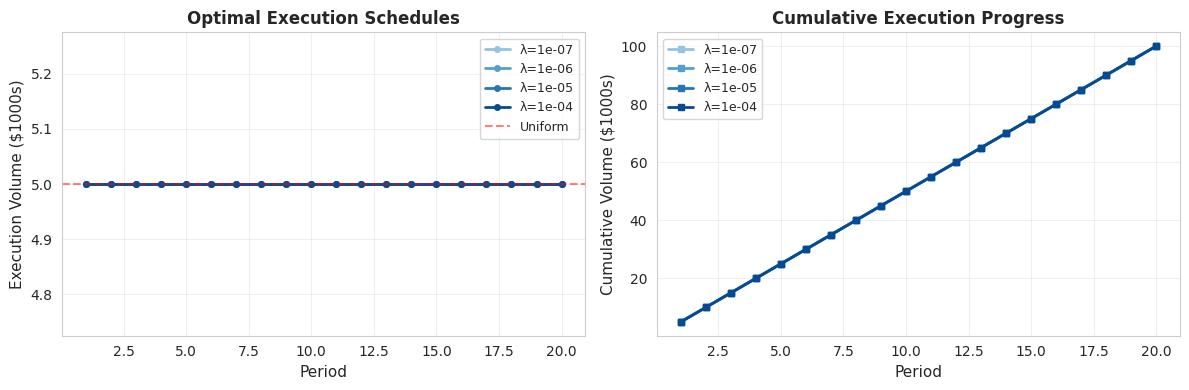


Interpretation:
  • Low λ (1e-7):  Aggressive execution (spread out quickly)
  • High λ (1e-4): Patient execution (minimize market impact)


In [9]:
# Visualize execution schedules
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Different schedules
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(lambda_values)))
for (lam, schedule), color in zip(schedules.items(), colors):
    axes[0].plot(range(1, 21), schedule/1000, marker='o', label=f'λ={lam:.0e}', 
                 linewidth=2, markersize=4, color=color)
axes[0].axhline(5, color='red', linestyle='--', alpha=0.5, label='Uniform')
axes[0].set_xlabel('Period', fontsize=11)
axes[0].set_ylabel('Execution Volume ($1000s)', fontsize=11)
axes[0].set_title('Optimal Execution Schedules', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: Cumulative execution
for (lam, schedule), color in zip(schedules.items(), colors):
    cumsum = np.cumsum(schedule)
    axes[1].plot(range(1, 21), cumsum/1000, marker='s', label=f'λ={lam:.0e}',
                 linewidth=2, markersize=4, color=color)
axes[1].set_xlabel('Period', fontsize=11)
axes[1].set_ylabel('Cumulative Volume ($1000s)', fontsize=11)
axes[1].set_title('Cumulative Execution Progress', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('  • Low λ (1e-7):  Aggressive execution (spread out quickly)')
print('  • High λ (1e-4): Patient execution (minimize market impact)')

## 4. High-Frequency Trading Metrics

Analyze trade dynamics including clustering, duration, and liquidity measures.

In [10]:
# Generate realistic trade data
np.random.seed(42)
n_trades = 2000

# Geometric Brownian Motion for prices
log_returns = np.random.normal(-0.0001, 0.005, n_trades)
prices = 100.0 * np.exp(np.cumsum(log_returns))

# Inter-arrival times (exponential)
inter_arrival = np.random.exponential(0.05, n_trades)
timestamps = np.cumsum(inter_arrival)

# Volumes (gamma distributed)
volumes = np.random.gamma(2, 500, n_trades)

trade_data = pd.DataFrame({
    'timestamp': timestamps,
    'price': prices,
    'quantity': volumes,
})

print(f'Generated {len(trade_data)} trades')
print(f'Price range: ${trade_data["price"].min():.2f} - ${trade_data["price"].max():.2f}')
print(f'Avg volume: {trade_data["quantity"].mean():.0f} shares')
print(f'Time span: {trade_data["timestamp"].max():.1f} seconds')

Generated 2000 trades
Price range: $85.33 - $135.03
Avg volume: 993 shares
Time span: 96.5 seconds


In [11]:
# Compute HFT metrics
metrics = HighFrequencyMetrics(trade_data)

realized_vol = metrics.compute_realized_volatility(window=50).mean()
amihud = metrics.compute_amihud_illiquidity()
roll_spread = metrics.compute_roll_spread()
clustering = metrics.compute_order_clustering()
duration = metrics.compute_order_duration()

print('HIGH-FREQUENCY TRADING METRICS')
print('=' * 70)
print(f'\nVolatility:')
print(f'  Realized Vol (annualized): {realized_vol:.4f}')

print(f'\nLiquidity Measures:')
print(f'  Amihud Illiquidity: {amihud:.8f}')
print(f'  Roll Spread Estimate: {roll_spread:.8f}')

print(f'\nOrder Clustering:')
print(f'  Fano Factor: {clustering["fano_factor"]:.4f}')
print(f'  Clustering Detected: {clustering["clustering_detected"]}')
print(f'  Hurst Exponent: {clustering["hurst_exponent"]:.4f}')

print(f'\nOrder Duration (seconds):')
for key, value in duration.items():
    print(f'  {key}: {value:.4f}')

HIGH-FREQUENCY TRADING METRICS

Volatility:
  Realized Vol (annualized): 1.5461

Liquidity Measures:
  Amihud Illiquidity: 0.00000007
  Roll Spread Estimate: 0.08040328

Order Clustering:
  Fano Factor: 1.0566
  Clustering Detected: False
  Hurst Exponent: 0.8819

Order Duration (seconds):
  mean_duration: 0.0483
  std_duration: 0.0484
  median_duration: 0.0336
  min_duration: 0.0000
  max_duration: 0.3862


/home/kjmetzler/Quant Research Portfolio/06_market_microstructure/market_microstructure.py:399: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trade_counts = self.trade_data.groupby(time_bins).size()


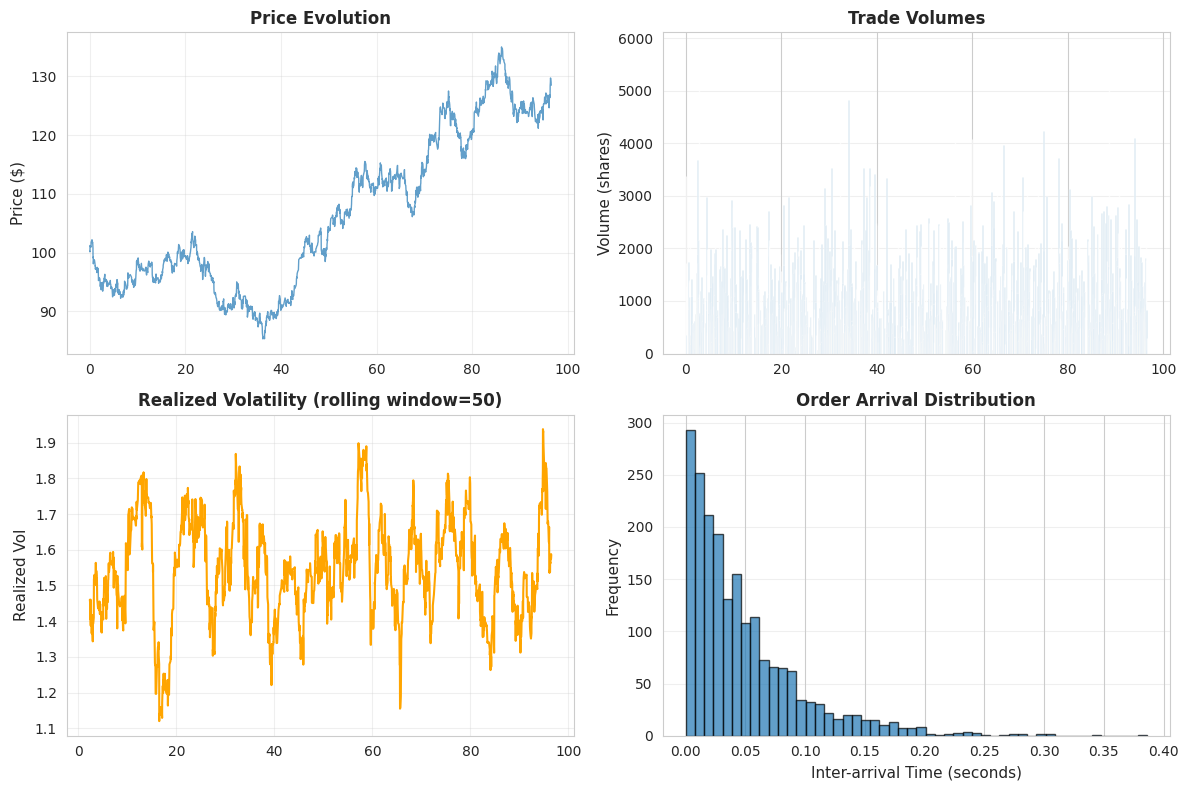

In [12]:
# Visualize HFT metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Price evolution
axes[0, 0].plot(trade_data['timestamp'], trade_data['price'], linewidth=1, alpha=0.7)
axes[0, 0].set_ylabel('Price ($)', fontsize=11)
axes[0, 0].set_title('Price Evolution', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Trade volumes
axes[0, 1].bar(trade_data['timestamp'], trade_data['quantity'], width=0.1, alpha=0.7)
axes[0, 1].set_ylabel('Volume (shares)', fontsize=11)
axes[0, 1].set_title('Trade Volumes', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Realized volatility
rv = metrics.compute_realized_volatility(window=50).dropna()
axes[1, 0].plot(trade_data['timestamp'].loc[rv.index], rv.values, linewidth=1.5, color='orange')
axes[1, 0].set_ylabel('Realized Vol', fontsize=11)
axes[1, 0].set_title('Realized Volatility (rolling window=50)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Inter-arrival time distribution
inter_arrivals = np.diff(trade_data['timestamp'].values)
axes[1, 1].hist(inter_arrivals[inter_arrivals < 1.0], bins=50, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Inter-arrival Time (seconds)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Order Arrival Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Summary & Key Insights

This module provides tools for understanding and analyzing market microstructure at high frequency.

In [13]:
# Generate comprehensive summary
summary = microstructure_summary(trade_data)

print('\nMICROSTRUCTURE SUMMARY')
print('=' * 70)
print(summary.to_string())

print('\n\nKEY INSIGHTS FROM THIS MODULE:')
print('=' * 70)
print('''
1. ORDER BOOK DYNAMICS
   • Spreads vary over time reflecting liquidity conditions
   • Imbalance predicts short-term price movements
   • Decomposition separates info vs. inventory costs

2. MARKET IMPACT
   • Temporary impact dominates (quick recovery)
   • Power-law (concave) impact empirically observed
   • Impact increases with order size and market stress

3. OPTIMAL EXECUTION
   • Risk aversion controls aggressiveness
   • Patient execution (high λ) reduces market impact
   • Trade-off: timing risk vs. implementation shortfall

4. HIGH-FREQUENCY METRICS
   • Orders cluster non-randomly (Fano > 1)
   • Persistent clustering (Hurst > 0.5)
   • Amihud measure quantifies illiquidity

5. PRACTICAL APPLICATIONS
   • Design better execution algorithms
   • Estimate liquidity and trading costs
   • Detect market microstructure changes
   • Optimize post-trade analysis
''')


MICROSTRUCTURE SUMMARY
   realized_volatility  amihud_illiquidity  roll_spread                                                                                                                                                           order_clustering                                                                                                                                                                                  order_duration
0             1.533872        7.483758e-08     0.080403  {'mean_trades_per_bin': 20.0, 'variance_trades': 21.13131313131313, 'fano_factor': 1.0565656565603738, 'clustering_detected': False, 'hurst_exponent': 0.881869640730894}  {'mean_duration': 0.04826834214838589, 'std_duration': 0.04836530188781624, 'median_duration': 0.03363234532713477, 'min_duration': 5.817411512509807e-07, 'max_duration': 0.3861764761031239}


KEY INSIGHTS FROM THIS MODULE:

1. ORDER BOOK DYNAMICS
   • Spreads vary over time reflecting liquidity conditions
   • Imbalance predic

/home/kjmetzler/Quant Research Portfolio/06_market_microstructure/market_microstructure.py:399: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trade_counts = self.trade_data.groupby(time_bins).size()
